# 平面波の解

ポテンシャルが存在しないとき、3次元の「定常状態におけるシュレーディンガー方程式」の解は平面波の形をとる。

* TISE = Time Independent Schrodinger Equation = 時間に依存しないシュレーディンガー方程式 = 定常状態におけるシュレーディンガー方程式
* TDSE = Time Dependent Schrodinger Equation = 時間に依存するシュレーディンガー方程式

In [60]:
import numpy as np
import matplotlib.pyplot as plt

HBAR = 1.054571817e-34   # J·s
M_E  = 9.1093837015e-31  # kg
PI = np.pi
simple = True

class KGrid:
    """
    KGrid Sampling
    n : sampling number.
    """
    def __init__(self, k_max=int):
        #for simplicity, set L=2pi, which means sampling grid corresponds to the natural lattice of allowed states
        ax = np.arange(-k_max, k_max, 1)
        self.kx, self.ky, self.kz = np.meshgrid(ax, ax, ax, indexing="ij")

    @property
    def k_squared(self):
        return self.kx**2 + self.ky**2 + self.kz**2
    

    def count_states_discrete(self, k_F=int, spin=2):
        mask = self.k_squared <= k_F**2     #broadcasting
        N = np.count_nonzero(mask)
        return N * spin
    
    def count_states_continuous(self, k_F=int, spin=2):
        N = 4*PI/3*k_F**3
        return N * spin

# def PlotKgrid(Kgrid):
#     fig = plt.figure(figsize=(25, 5))
#     for i, (label, cval) in enumerate([("kx", Kgrid.kx), ("ky", Kgrid.ky), ("kz", Kgrid.kz)]):
#         ax = fig.add_subplot(1, 3, i+1, projection="3d")
#         sc = ax.scatter(Kgrid.kx, Kgrid.ky, Kgrid.kz, c=cval, cmap="coolwarm", s=25, depthshade=False)
#         ax.set_xlabel("kx"); ax.set_ylabel("ky"); ax.set_zlabel("kz")
#         ax.set_title(f"color = {label}")
#         fig.colorbar(sc, ax=ax, shrink=0.5)
#     plt.tight_layout()
#     plt.show()

# testkgrid = KGrid(3)
# testkgrid2 = KGrid(5)
# print(f"{testkgrid.kx=}")
# testksquared = testkgrid.k_squared
# print(f"{testksquared=}")

# PlotKgrid(testkgrid)
# PlotKgrid(testkgrid2)

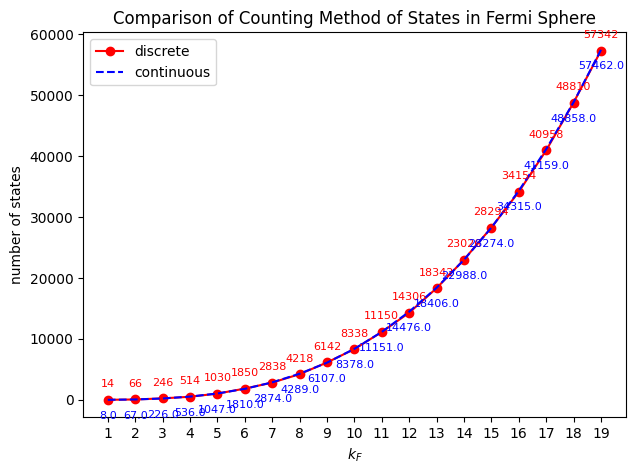

In [ ]:

KGrid1 = KGrid(30)

# print(f"{(KGrid.count_states_discrete(k_F=10))}")
# print(f"{(KGrid.count_states_continuous(k_F=10))}")

k_F_values=range(1, 20)

def PlotStateCount(grid, k_F_values):
    discrete_counts = [grid.count_states_discrete(k_F=k_F) for k_F in k_F_values]
    continuous_counts = [grid.count_states_continuous(k_F=k_F) for k_F in k_F_values]

    fig, ax = plt.subplots(figsize=(7,5))
    ax.plot(k_F_values, discrete_counts, "o-", label="discrete", color="red")
    ax.plot(k_F_values, continuous_counts, "--", label="continuous", color="blue")
    ax.set_xlabel("$k_F$")
    ax.set_xticks(k_F_values)
    ax.set_ylabel("number of states")
    ax.set_title("Comparison of Counting Method of States in Fermi Sphere")
    ax.legend()
    for x, y in zip(k_F_values, discrete_counts):
        ax.annotate(str(y), (x, y),
                    textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=8, color="red")
    for x, y in zip(k_F_values, np.round(continuous_counts)):
        ax.annotate(str(y), (x, y),
                    textcoords="offset points", xytext=(0, -14),
                    ha="center", fontsize=8, color="blue")
    plt.show()
    

PlotStateCount(KGrid1, k_F_values)

#It is fascinating that results of two methods are very similar even small k_F!
